# Head Detection with RetinaNet on Hollywood Heads Dataset

Lab Assignment from AI for Beginners Curriculum.

## Imports 

In [18]:
import os
import zipfile
import urllib.request
import glob
import random
import xml.etree.ElementTree as ET

import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.transforms import functional as F

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

## Explore Dataset

In [19]:
dataset_dir = "HollywoodHeads"

# List some images and annotation files
images_path = os.path.join(dataset_dir, "JPEGImages")
annots_path = os.path.join(dataset_dir, "Annotations")

image_files = sorted(glob.glob(os.path.join(images_path, "*.jpeg")))
annot_files = sorted(glob.glob(os.path.join(annots_path, "*.xml")))

print("Sample image files:")
for img in image_files[:3]:
    print(os.path.basename(img))

print("\nSample annotation files:")
for ann in annot_files[:3]:
    print(os.path.basename(ann))

sample_annot = annot_files[0]
with open(sample_annot, "r") as f:
    xml_content = f.read()
print("\nSample annotation XML:")
print("\n".join(xml_content.splitlines()[:20]))  # Show first 20 lines

Sample image files:
mov_001_007585.jpeg
mov_001_007586.jpeg
mov_001_007587.jpeg

Sample annotation files:
mov_001_007585.xml
mov_001_007586.xml
mov_001_007587.xml

Sample annotation XML:
<annotation>
	<folder>HollywoodHeads</folder>
	<filename>mov_001_007585.jpeg</filename>
	<source>
		<database>HollywoodHeads 2015 Database</database>
		<annotation>HollywoodHeads 2015</annotation>
		<image>WILLOW</image>
	</source>
	<size>
		<width>528</width>
		<height>224</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>head</name>
		<bndbox>
			<xmin>246</xmin>
			<ymin>6</ymin>
			<xmax>299</xmax>


## Parse PASCAL VOC Annotations

In [20]:
def parse_voc_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    boxes = []
    for obj in root.findall("object"):
        name_elem = obj.find("name")
        if name_elem is None:  
            continue
        name = name_elem.text

        if name != "head":
            continue
        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)
        boxes.append([xmin, ymin, xmax, ymax])
    return boxes

# Parse a sample annotation
sample_boxes = parse_voc_xml(sample_annot)
print(f"Parsed bounding boxes from {os.path.basename(sample_annot)}:")
print(sample_boxes)

Parsed bounding boxes from mov_001_007585.xml:
[[246.0, 6.0, 299.0, 76.0]]


## Visualize Sample Images with Bounding Boxes

Image: mov_003_160670.jpeg


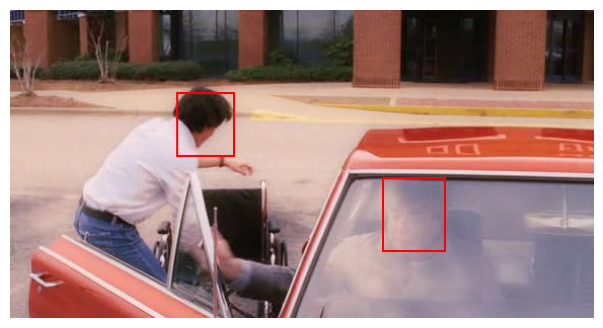

Image: mov_012_062163.jpeg


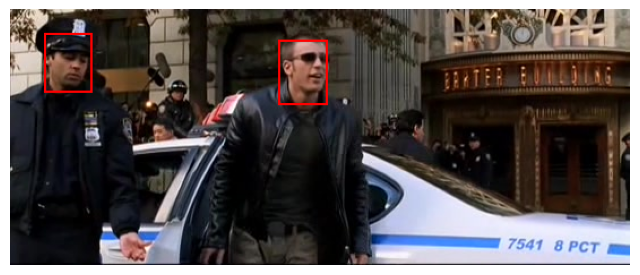

Image: mov_013_021758.jpeg


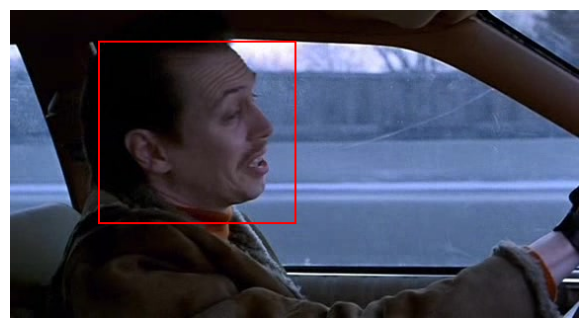

In [21]:
def plot_image_with_boxes(img_path, boxes):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    for box in boxes:
        draw.rectangle(box, outline="red", width=2)
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Visualize 3 random samples
for i in range(3):
    idx = random.randint(0, len(image_files) - 1)
    img_path = image_files[idx]
    annot_path = annot_files[idx]
    boxes = parse_voc_xml(annot_path)
    print(f"Image: {os.path.basename(img_path)}")
    plot_image_with_boxes(img_path, boxes)

## Prepare Dataset for PyTorch

In [22]:
def prepare_target(boxes):
    boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    labels = torch.ones((boxes.shape[0],), dtype=torch.int64)  # All are 'head' class
    target = {"boxes": boxes, "labels": labels}
    return target

# Example for one image
img = Image.open(image_files[0]).convert("RGB")
boxes = parse_voc_xml(annot_files[0])
target = prepare_target(boxes)
print("Target dictionary example:")
print(target)

Target dictionary example:
{'boxes': tensor([[246.,   6., 299.,  76.]]), 'labels': tensor([1])}


## Create PyTorch Dataset and DataLoader

In [23]:
class HollywoodHeadsDataset(Dataset):
    def __init__(self, image_files, annot_files, transforms=None):
        self.image_files = image_files
        self.annot_files = annot_files
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        annot_path = self.annot_files[idx]
        img = Image.open(img_path).convert("RGB")
        boxes = parse_voc_xml(annot_path)
        target = prepare_target(boxes)
        if self.transforms:
            img = self.transforms(img)
        else:
            img = F.to_tensor(img)
        return img, target

indices = list(range(len(image_files)))
random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_imgs = [image_files[i] for i in train_idx]
train_anns = [annot_files[i] for i in train_idx]
val_imgs = [image_files[i] for i in val_idx]
val_anns = [annot_files[i] for i in val_idx]

train_dataset = HollywoodHeadsDataset(train_imgs, train_anns)
val_dataset = HollywoodHeadsDataset(val_imgs, val_anns)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 179792, Val samples: 44948


## Load Pretrained RetinaNet Model

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = retinanet_resnet50_fpn(weights="DEFAULT")
num_classes = 2  # 1 class ('head') + background

# Replace the head
in_features = 256
num_anchors = model.head.classification_head.num_anchors
model.head.classification_head = torchvision.models.detection.retinanet.RetinaNetClassificationHead(
    in_channels=in_features, num_anchors=num_anchors, num_classes=num_classes
)

model = model.to(device)
print("Model loaded and moved to device:", device)

Model loaded and moved to device: cuda


In [25]:
import torch
print(torch.version.cuda)   # should print the CUDA version compiled with PyTorch
print(torch.cuda.is_available())  # should be True if CUDA is working
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")


12.1
True
NVIDIA GeForce RTX 3070 Laptop GPU


## Train RetinaNet on Hollywood Heads

In [26]:
# Training parameters
num_epochs = 2  # For demonstration, increase for real training
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        running_loss += losses.item()
    lr_scheduler.step()
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")

Epoch 1/2: 100%|██████████| 44948/44948 [23:15:48<00:00,  1.86s/it]   


Epoch 1 - Average Loss: 0.3158


Epoch 2/2: 100%|██████████| 44948/44948 [20:08:17<00:00,  1.61s/it]   

Epoch 2 - Average Loss: 0.2232


## 10. Evaluate Model Performance

We will evaluate the trained model on the validation set, calculating metrics such as IoU. We'll display sample evaluation results.

In [27]:
def compute_iou(boxA, boxB):
    # boxA and boxB are [xmin, ymin, xmax, ymax]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

model.eval()
ious = []
with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images = [img.to(device) for img in images]
        outputs = model(images)
        for output, target in zip(outputs, targets):
            pred_boxes = output['boxes'].cpu()
            gt_boxes = target['boxes']
            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue
            # Compute IoU for first predicted and first gt box (demo)
            iou = compute_iou(pred_boxes[0], gt_boxes[0])
            ious.append(iou)
if ious:
    print(f"Mean IoU on validation set (first box per image): {sum(ious)/len(ious):.3f}")
else:
    print("No predictions to compute IoU.")

Evaluating: 100%|██████████| 11237/11237 [2:14:04<00:00,  1.40it/s] 

Mean IoU on validation set (first box per image): 0.659


## 11. Run Inference and Visualize Predictions

Let's run inference on a few test images and visualize the predicted bounding boxes alongside ground truth boxes.

Image: mov_006_141081.jpeg


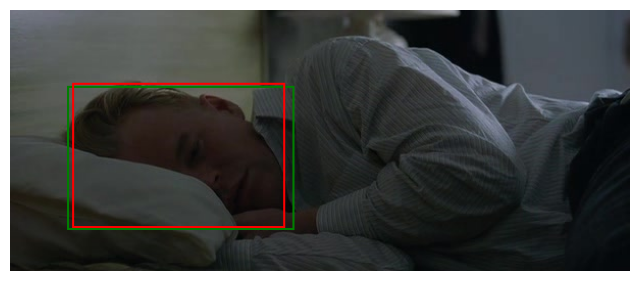

Image: mov_012_025647.jpeg


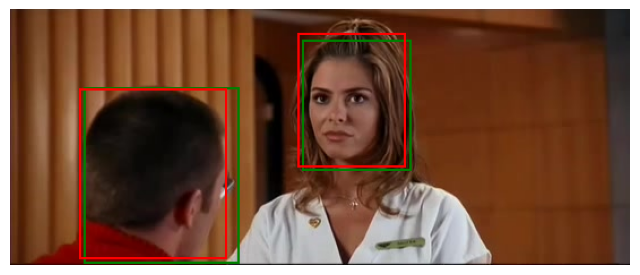

Image: mov_010_047953.jpeg


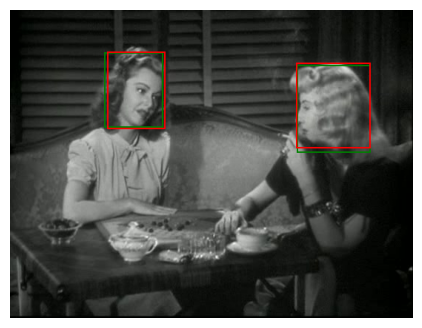

In [28]:
def plot_pred_vs_gt(img_path, gt_boxes, pred_boxes, pred_scores, score_thresh=0.5):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    # Draw ground truth in green
    for box in gt_boxes:
        draw.rectangle(box, outline="green", width=2)
    # Draw predictions in red
    for box, score in zip(pred_boxes, pred_scores):
        if score >= score_thresh:
            draw.rectangle(box.tolist(), outline="red", width=2)
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

model.eval()
for i in range(3):
    idx = random.randint(0, len(val_imgs) - 1)
    img_path = val_imgs[idx]
    img = Image.open(img_path).convert("RGB")
    img_tensor = F.to_tensor(img).to(device)
    with torch.no_grad():
        output = model([img_tensor])[0]
    pred_boxes = output['boxes'].cpu()
    pred_scores = output['scores'].cpu()
    gt_boxes = parse_voc_xml(val_anns[idx])
    print(f"Image: {os.path.basename(img_path)}")
    plot_pred_vs_gt(img_path, gt_boxes, pred_boxes, pred_scores)